#### 銘柄分析：　既存のAnalyzerとその他の指標を組み合わせて先行きを見ていきたい：

#### ソフトバンクGやNTTあたりで見てみるか

### 参考：https://note.com/botter_01/n/nbbec5830cc17

In [4]:
import pandas as pd
import yfinance as yf 
import numpy as np 
import matplotlib.pyplot as plt
import datetime
import seaborn as sns 
from kazustat import YFinanceAnalysis
import warnings 

In [5]:
warnings.filterwarnings("ignore")

#### ソフトバンクG　9984

Plotting for 9984.T


[*********************100%***********************]  1 of 1 completed


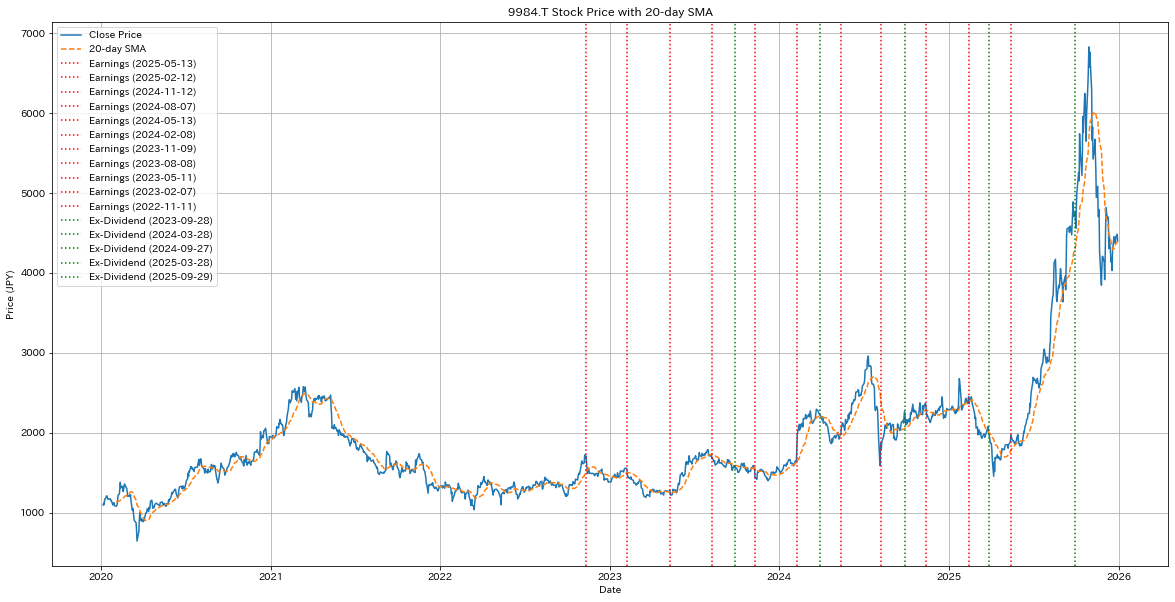

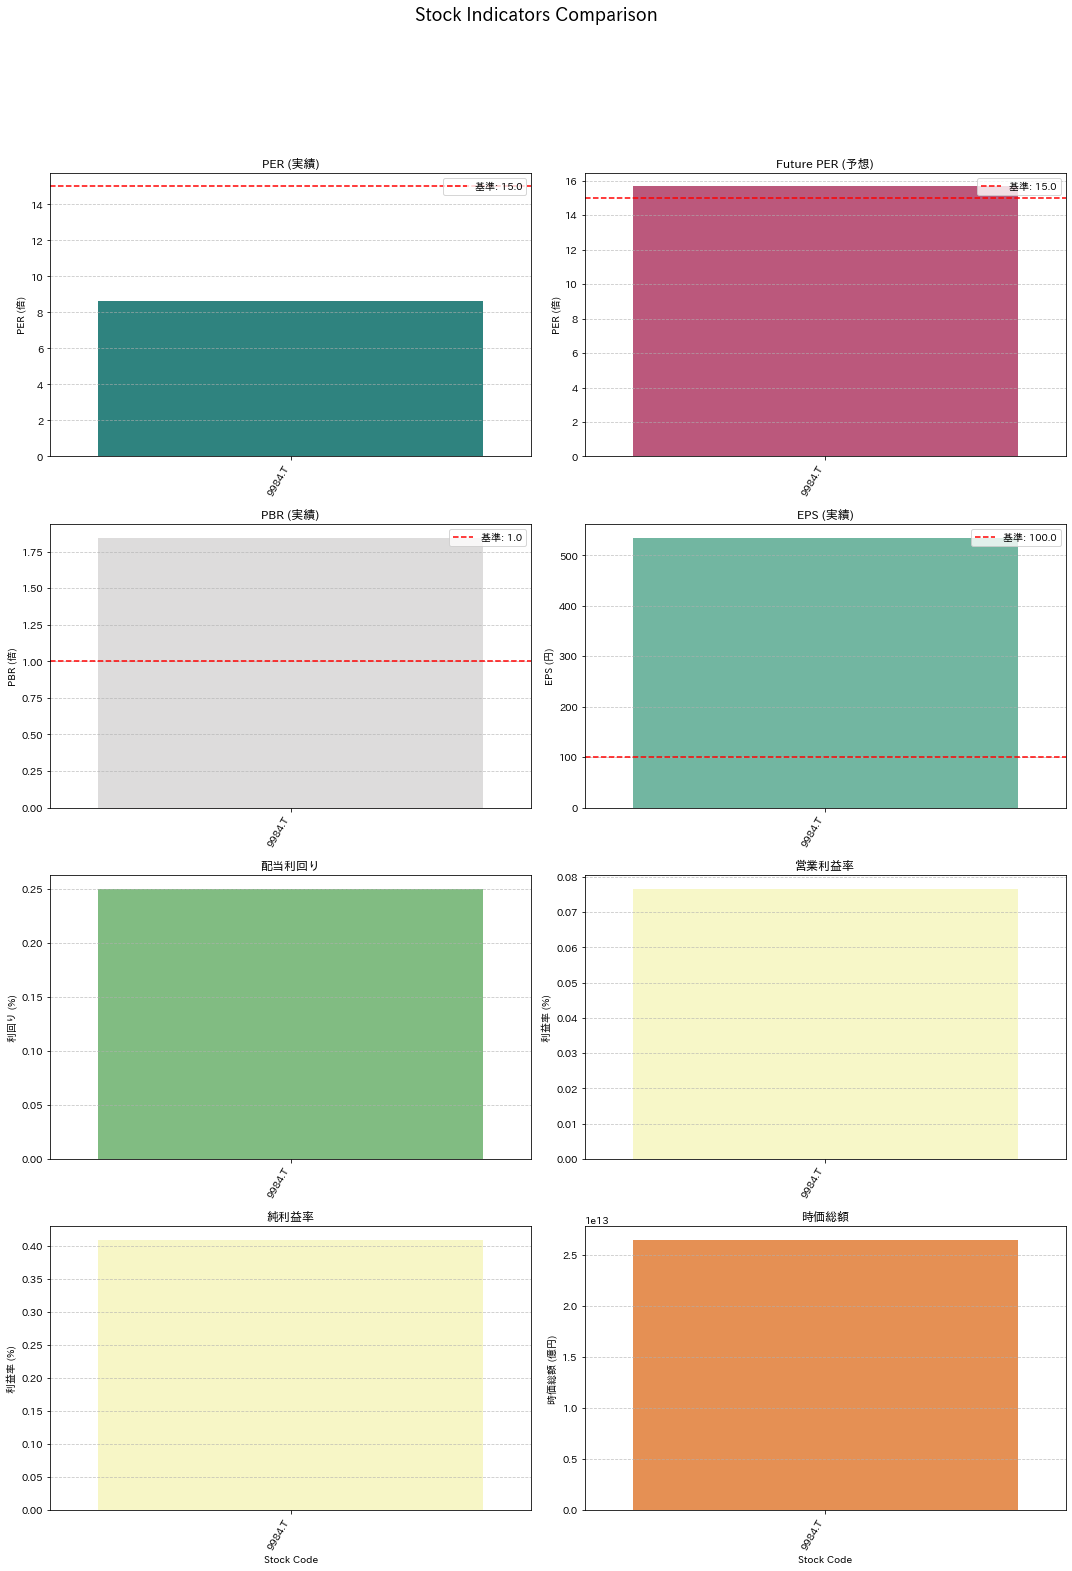

In [6]:
analyzer = YFinanceAnalysis(codes=['9984.T'], start='2020-01-01', end='2025-12-31')
analyzer.describe_codes()

#### 日経平均の業種ごとのIndexを計算して可視化したい：　将来性も含めて

In [16]:
nikkei = yf.download("^N225", start="2020-01-01", end="2025-12-31")
softbank = yf.download("9984.T", start="2020-01-01", end="2025-12-31")
dat = yf.Ticker("^N225")

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


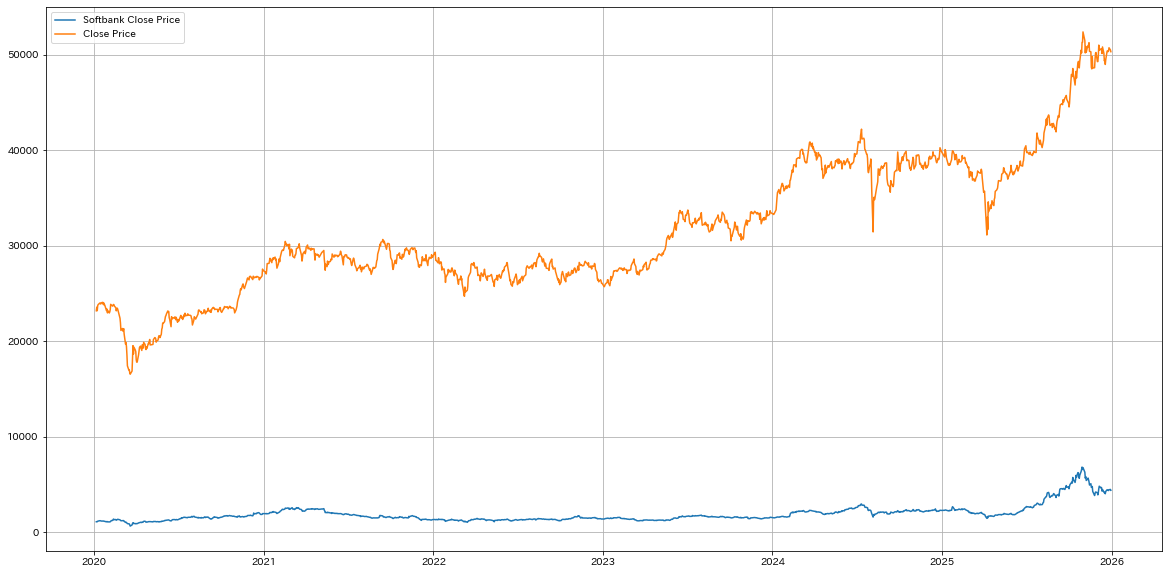

In [20]:
df = nikkei.reset_index().copy()
sf = softbank.reset_index().copy()
sf.columns = ['Date', "Close_SB", "High_SB", "Low_SB", "Open_SB", "Volume_SB"]
df.columns = ['Date', "Close", "High", "Low", "Open", "Volume"]
plt.figure(figsize=(20,10))
plt.plot(sf['Date'],sf["Close_SB"], label="Softbank Close Price")
plt.plot(df['Date'],df["Close"], label="Close Price")
plt.grid()
plt.legend()
plt.show()

In [23]:
# 業種ごとのNikkei上昇率をHeatmapで表示したい：
TOPIX_LIST_URL = "/Users/yoshizawakazuki/Downloads/topixweight_j.csv"
df_list = pd.read_csv(TOPIX_LIST_URL, encoding="shift_jis").dropna()
df_list = df_list.rename(columns={
    '日付': 'Date',
    'コード': 'Code',
    '銘柄名': 'CompanyName',
    '業種': 'Sector33CodeName',
    'ニューインデックス区分': 'ScaleCategory',
})
df_list

,Date,CompanyName,Code,Sector33CodeName,TOPIXに占める個別銘柄のウエイト,ScaleCategory
0,20251128,極洋,1301,水産・農林業,0.0059%,TOPIX Small 1
1,20251128,ニッスイ,1332,水産・農林業,0.0331%,TOPIX Mid400
2,20251128,マルハニチロ,1333,水産・農林業,0.0180%,TOPIX Mid400
3,20251128,ユキグニファクトリー,1375,水産・農林業,0.0026%,TOPIX Small 2
4,20251128,カネコ種苗,1376,水産・農林業,0.0013%,TOPIX Small 2
...,...,...,...,...,...,...
1663,20251128,スズケン,9987,卸売業,0.0444%,TOPIX Mid400
1664,20251128,サンドラッグ,9989,小売業,0.0282%,TOPIX Mid400
1665,20251128,サックスバー ホールディングス,9990,小売業,0.0014%,TOPIX Small 2
1666,20251128,ジェコス,9991,卸売業,0.0023%,TOPIX Small 2


In [25]:
categories = ['TOPIX Mid400', 'TOPIX Large70', 'TOPIX Core30']

tickers = df_list[df_list['ScaleCategory'].isin(categories)]['Code'].unique()
tickers = tickers.astype(str).tolist()

tickers

['1332',
 '1333',
 '1414',
 '1417',
 '1605',
 '1719',
 '1721',
 '1801',
 '1802',
 '1803',
 '1808',
 '1812',
 '1820',
 '1860',
 '1878',
 '1893',
 '1911',
 '1925',
 '1928',
 '1942',
 '1944',
 '1951',
 '1959',
 '1963',
 '1969',
 '2002',
 '2127',
 '2181',
 '2201',
 '2206',
 '2212',
 '2222',
 '2229',
 '2264',
 '2267',
 '2269',
 '2282',
 '2327',
 '2331',
 '2371',
 '2413',
 '2432',
 '2433',
 '2501',
 '2502',
 '2503',
 '2531',
 '2579',
 '2587',
 '2593',
 '2607',
 '2670',
 '2768',
 '2784',
 '2801',
 '2802',
 '2809',
 '2810',
 '2811',
 '285A',
 '2871',
 '2875',
 '2897',
 '2914',
 '3003',
 '3038',
 '3048',
 '3064',
 '3086',
 '3088',
 '3092',
 '3099',
 '3105',
 '3107',
 '3116',
 '3132',
 '3197',
 '3231',
 '3288',
 '3289',
 '3291',
 '3349',
 '3360',
 '3382',
 '3391',
 '3397',
 '3401',
 '3402',
 '3405',
 '3407',
 '3436',
 '3549',
 '3563',
 '3591',
 '3626',
 '3635',
 '3659',
 '3697',
 '3769',
 '3774',
 '3861',
 '3923',
 '3941',
 '3994',
 '4004',
 '4005',
 '4021',
 '4042',
 '4043',
 '4045',
 '4061',
 

In [28]:
len(tickers)

497

In [26]:
def download_yf_daily(start="2015-01-01", end=None, chunk_size=50, tickers=['7203']):
    """Download daily prices for tickers in manageable batches."""

    tickers_yf = [f"{code}.T" for code in tickers]
    frames = []
    for i in range(0, len(tickers_yf), chunk_size):
        batch = tickers_yf[i : i + chunk_size]
        data = yf.download(
            tickers=batch,
            start=start,
            end=end,
            interval="1d",
            auto_adjust=True,
            progress=False,
        )
        if data.empty:
            continue
        if isinstance(data.columns, pd.MultiIndex):
            batch_df = data.stack(level=-1).rename_axis(index=["Date", "Ticker"]).reset_index()
        else:
            batch_df = data.reset_index().assign(Ticker=batch[0])
        frames.append(batch_df)

    prices = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    return prices

df_ohlcv = download_yf_daily(tickers=tickers)
df_ohlcv['Code'] = df_ohlcv['Ticker'].str[:4]
df_ohlcv

Price,Date,Ticker,Close,High,Low,Open,Volume,Code
0,2015-01-05,1332.T,301.052124,303.473455,295.402352,302.666345,1831000.0,1332
1,2015-01-05,1333.T,484.839844,487.503783,477.647165,479.511917,546300.0,1333
2,2015-01-05,1414.T,463.391083,465.848087,457.985672,463.391083,617600.0,1414
3,2015-01-05,1417.T,990.375793,1003.541794,988.181460,999.153127,236500.0,1417
4,2015-01-05,1605.T,918.474670,933.457376,913.945015,932.412071,4189400.0,1605
...,...,...,...,...,...,...,...,...
1307919,2026-01-06,9962.T,2518.500000,2552.500000,2504.500000,2528.500000,156700.0,9962
1307920,2026-01-06,9983.T,57680.000000,58010.000000,57150.000000,57390.000000,358500.0,9983
1307921,2026-01-06,9984.T,4617.000000,4710.000000,4531.000000,4690.000000,20551800.0,9984
1307922,2026-01-06,9987.T,6228.000000,6241.000000,6189.000000,6217.000000,60900.0,9987


In [27]:
len(df_ohlcv['Code'].unique())

497

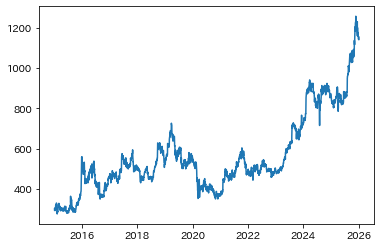

In [29]:
example = df_ohlcv[df_ohlcv['Code']=='1332']
plt.plot(example['Date'],example["Close"], label="Close Price")

In [30]:
df_merged = df_ohlcv.merge(
    df_list[['CompanyName','Code','Sector33CodeName','ScaleCategory']],
    on = ['Code']
)

df_merged

,Date,Ticker,Close,High,Low,Open,Volume,Code,CompanyName,Sector33CodeName,ScaleCategory
0,2015-01-05,1332.T,301.052124,303.473455,295.402352,302.666345,1831000.0,1332,ニッスイ,水産・農林業,TOPIX Mid400
1,2015-01-05,1333.T,484.839844,487.503783,477.647165,479.511917,546300.0,1333,マルハニチロ,水産・農林業,TOPIX Mid400
2,2015-01-05,1414.T,463.391083,465.848087,457.985672,463.391083,617600.0,1414,ショーボンドホールディングス,建設業,TOPIX Mid400
3,2015-01-05,1417.T,990.375793,1003.541794,988.181460,999.153127,236500.0,1417,ミライト・ワン,建設業,TOPIX Mid400
4,2015-01-05,1605.T,918.474670,933.457376,913.945015,932.412071,4189400.0,1605,ＩＮＰＥＸ,鉱業,TOPIX Mid400
...,...,...,...,...,...,...,...,...,...,...,...
1307919,2026-01-06,9962.T,2518.500000,2552.500000,2504.500000,2528.500000,156700.0,9962,ミスミグループ本社,卸売業,TOPIX Mid400
1307920,2026-01-06,9983.T,57680.000000,58010.000000,57150.000000,57390.000000,358500.0,9983,ファーストリテイリング,小売業,TOPIX Core30
1307921,2026-01-06,9984.T,4617.000000,4710.000000,4531.000000,4690.000000,20551800.0,9984,ソフトバンクグループ,情報・通信業,TOPIX Core30
1307922,2026-01-06,9987.T,6228.000000,6241.000000,6189.000000,6217.000000,60900.0,9987,スズケン,卸売業,TOPIX Mid400


In [31]:
df_merged['Sector33CodeName'].unique()

array(['水産・農林業', '建設業', '鉱業', '不動産業', '食料品', 'サービス業', '情報・通信業', '小売業',
       '卸売業', '電気機器', '輸送用機器', '繊維製品', '化学', '金属製品', 'パルプ・紙', '医薬品',
       '精密機器', '石油・石炭製品', 'ゴム製品', 'ガラス・土石製品', '非鉄金属', '鉄鋼', '機械', '銀行業',
       'その他金融業', 'その他製品', '保険業', '証券、商品先物取引業', '陸運業', '海運業', '空運業',
       '倉庫・運輸関連業', '電気・ガス業'], dtype=object)

### 業種別の変動指標を定義してHeatmap表示する方法　by ChatGPT

In [32]:
# 上昇率・変動率などの指標を定義したい：
import pandas as pd
df=df_merged
# Dateをdatetimeに
df['Date'] = pd.to_datetime(df['Date'])

# 銘柄ごとに並び替え
df = df.sort_values(['Ticker', 'Date'])

# 終値ベースの前日比上昇率（%）
df['Return'] = df.groupby('Ticker')['Close'].pct_change() * 100



In [34]:
sector_return = (
    df
    .groupby(['Date', 'Sector33CodeName'])['Return']
    .mean()
    .reset_index()
)

pivot = sector_return.pivot(
    index='Sector33CodeName',
    columns='Date',
    values='Return'
)


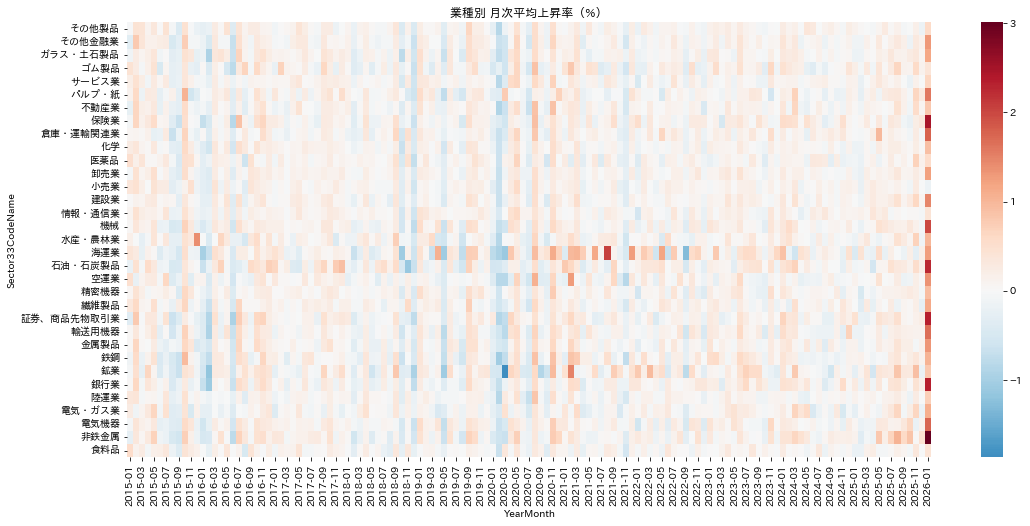

In [36]:
df['YearMonth'] = df['Date'].dt.to_period('M')

monthly = (
    df
    .groupby(['YearMonth', 'Sector33CodeName'])['Return']
    .mean()
    .reset_index()
)

pivot_m = monthly.pivot(
    index='Sector33CodeName',
    columns='YearMonth',
    values='Return'
)

plt.figure(figsize=(18, 8))
sns.heatmap(pivot_m, cmap='RdBu_r', center=0)
plt.title('業種別 月次平均上昇率（%）')
plt.show()


In [37]:
df_merged['Ticker']

0          1332.T
1          1333.T
2          1414.T
3          1417.T
4          1605.T
            ...  
1307919    9962.T
1307920    9983.T
1307921    9984.T
1307922    9987.T
1307923    9989.T
Name: Ticker, Length: 1307924, dtype: object

In [48]:
from tqdm import tqdm
tickinfo =[]

for _, i in enumerate(tqdm(df_merged['Ticker'].unique())):
    dat = yf.Ticker(i)
    info = dat.info
    try:
        per = info['trailingPE'] 
        pbr = info['priceToBook']
        eps = info['trailingEps']
        tickinfo.append({'Ticker':i,'PER':per,'PBR':pbr,'EPS':eps})
    except:
        pass

tickinfo



100%|██████████| 497/497 [02:41<00:00,  3.07it/s]


[{'Ticker': '1332.T', 'PER': 12.998632, 'PBR': 1.261057, 'EPS': 87.74},
 {'Ticker': '1333.T', 'PER': 9.103448, 'PBR': 0.8607339, 'EPS': 145.0},
 {'Ticker': '1414.T', 'PER': 18.723461, 'PBR': 2.7034402, 'EPS': 73.01},
 {'Ticker': '1417.T', 'PER': 15.926812, 'PBR': 1.2286735, 'EPS': 225.72},
 {'Ticker': '1605.T', 'PER': 8.328967, 'PBR': 0.79851675, 'EPS': 362.59},
 {'Ticker': '1719.T', 'PER': 11.595019, 'PBR': 1.672411, 'EPS': 168.65},
 {'Ticker': '1721.T', 'PER': 17.22988, 'PBR': 1.4280177, 'EPS': 269.88},
 {'Ticker': '1801.T', 'PER': 18.943054, 'PBR': 2.9616032, 'EPS': 817.45},
 {'Ticker': '1802.T', 'PER': 13.795272, 'PBR': 1.9514457, 'EPS': 238.56},
 {'Ticker': '1803.T', 'PER': 18.519773, 'PBR': 2.0603495, 'EPS': 147.41},
 {'Ticker': '1808.T', 'PER': 21.71203, 'PBR': 1.591794, 'EPS': 144.39},
 {'Ticker': '1812.T', 'PER': 16.953371, 'PBR': 2.1776066, 'EPS': 357.51},
 {'Ticker': '1820.T', 'PER': 12.66573, 'PBR': 1.2898873, 'EPS': 455.56},
 {'Ticker': '1860.T', 'PER': 12.812378, 'PBR': 1

In [49]:
df_merged.columns

Index(['Date', 'Ticker', 'Close', 'High', 'Low', 'Open', 'Volume', 'Code',
       'CompanyName', 'Sector33CodeName', 'ScaleCategory'],
      dtype='object')

In [50]:
df_merged['Sector33CodeName'].unique()

array(['水産・農林業', '建設業', '鉱業', '不動産業', '食料品', 'サービス業', '情報・通信業', '小売業',
       '卸売業', '電気機器', '輸送用機器', '繊維製品', '化学', '金属製品', 'パルプ・紙', '医薬品',
       '精密機器', '石油・石炭製品', 'ゴム製品', 'ガラス・土石製品', '非鉄金属', '鉄鋼', '機械', '銀行業',
       'その他金融業', 'その他製品', '保険業', '証券、商品先物取引業', '陸運業', '海運業', '空運業',
       '倉庫・運輸関連業', '電気・ガス業'], dtype=object)

In [52]:
df_merged[['Ticker','Sector33CodeName']]

,Ticker,Sector33CodeName
0,1332.T,水産・農林業
1,1333.T,水産・農林業
2,1414.T,建設業
3,1417.T,建設業
4,1605.T,鉱業
...,...,...
1307919,9962.T,卸売業
1307920,9983.T,小売業
1307921,9984.T,情報・通信業
1307922,9987.T,卸売業


In [54]:
xxxx = pd.DataFrame(tickinfo)
infodf = pd.merge(xxxx,df_merged[['Ticker','Sector33CodeName']],on='Ticker')

In [56]:
infodf = infodf.drop_duplicates()

In [57]:
infodf

,Ticker,PER,PBR,EPS,Sector33CodeName
0,1332.T,12.998632,1.261057,87.74,水産・農林業
2711,1333.T,9.103448,0.860734,145.00,水産・農林業
5422,1414.T,18.723461,2.703440,73.01,建設業
8133,1417.T,15.926812,1.228673,225.72,建設業
10844,1605.T,8.328967,0.798517,362.59,鉱業
...,...,...,...,...,...
1235417,9984.T,8.702727,1.855598,534.66,情報・通信業
1238128,9987.T,14.855949,1.079139,421.38,卸売業
1240839,9989.T,15.657235,1.791901,271.44,小売業
1243550,9434.T,19.163700,3.534624,11.24,情報・通信業


<Axes: xlabel='PER', ylabel='PBR'>

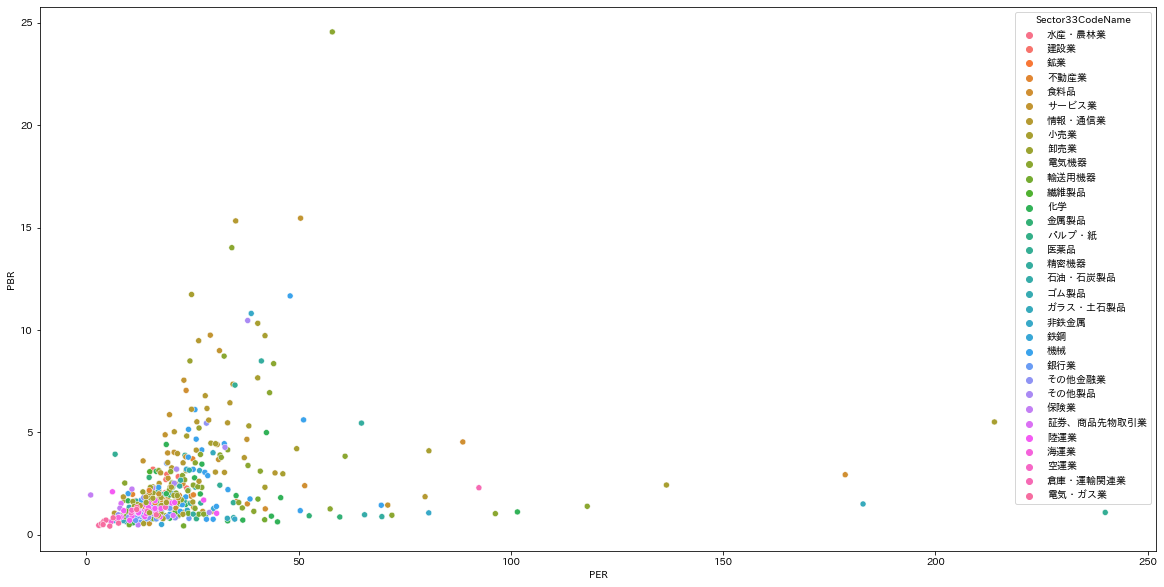

In [65]:
import seaborn as sns 

plt.figure(figsize=(20,10))
sns.scatterplot(data=infodf,x='PER',y='PBR',hue='Sector33CodeName',legend='full')
# plt.xlim(0,10)
# plt.ylim(0,1)

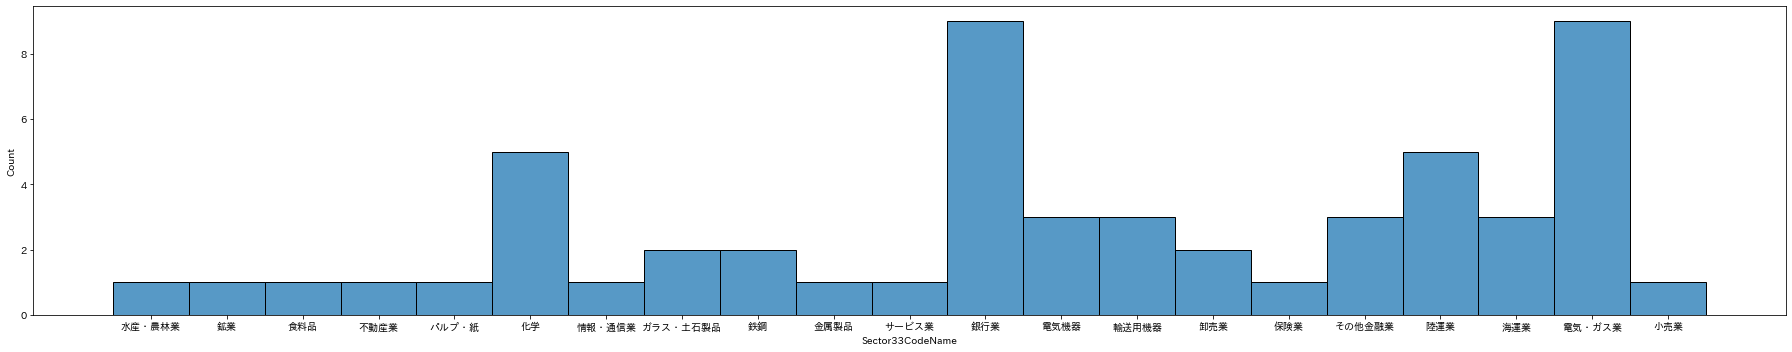

In [71]:
plt.figure(figsize=(25,5))
sns.histplot(x='Sector33CodeName',data=infodf[(infodf['PER']<15)&(infodf['PBR']<1.0)])
plt.tight_layout()
plt.show()

In [74]:
valuedf = infodf[(infodf['PER']<15)&(infodf['PBR']<1.0)]
valuedf[valuedf['Sector33CodeName']=='化学']['Ticker'].unique()

array(['4005.T', '4118.T', '4205.T', '4272.T', '4631.T'], dtype=object)

In [76]:
import pandas as pd

# 東証プライム銘柄リスト取得（例：日証協CSV）
url = "https://www.jpx.co.jp/markets/statistics-equities/misc/tvdivq0000001vg2-att/data_j.xls"
df_master = pd.read_excel(url, sheet_name="Sheet1", dtype={"コード": str})

# コード桁数補正
df_master["コード"] = df_master["コード"].str.zfill(4)

# 銘柄コード + 名前 + 業種カラムだけ抽出
df_master = df_master[["コード", "銘柄名", "33業種区分"]]
df_master.columns = ["ticker", "name", "sector"]
len(df_master)


4437

In [81]:
u = pd.read_excel('/Users/yoshizawakazuki/Desktop/tosho.xls')
u

,日付,コード,銘柄名,市場・商品区分,33業種コード,33業種区分,17業種コード,17業種区分,規模コード,規模区分
0,20251231,1301,極洋,プライム（内国株式）,50,水産・農林業,1,食品,6,TOPIX Small 1
1,20251231,1305,ｉＦｒｅｅＥＴＦ ＴＯＰＩＸ（年１回決算型）,ETF・ETN,-,-,-,-,-,-
2,20251231,1306,ＮＥＸＴ ＦＵＮＤＳ ＴＯＰＩＸ連動型上場投信,ETF・ETN,-,-,-,-,-,-
3,20251231,1308,上場インデックスファンドＴＯＰＩＸ,ETF・ETN,-,-,-,-,-,-
4,20251231,1309,ＮＥＸＴ ＦＵＮＤＳ ＣｈｉｎａＡＭＣ・中国株式・上証５０連動型上場投信,ETF・ETN,-,-,-,-,-,-
...,...,...,...,...,...,...,...,...,...,...
4432,20251231,9991,ジェコス,プライム（内国株式）,6050,卸売業,13,商社・卸売,7,TOPIX Small 2
4433,20251231,9993,ヤマザワ,スタンダード（内国株式）,6100,小売業,14,小売,-,-
4434,20251231,9994,やまや,スタンダード（内国株式）,6100,小売業,14,小売,-,-
4435,20251231,9996,サトー商会,スタンダード（内国株式）,6050,卸売業,13,商社・卸売,-,-


In [82]:
u.columns

Index(['日付', 'コード', '銘柄名', '市場・商品区分', '33業種コード', '33業種区分', '17業種コード', '17業種区分',
       '規模コード', '規模区分'],
      dtype='object')

In [83]:
u['市場・商品区分'].unique()

array(['プライム（内国株式）', 'ETF・ETN', 'グロース（内国株式）', 'PRO Market',
       'スタンダード（内国株式）', 'プライム（外国株式）', 'REIT・ベンチャーファンド・カントリーファンド・インフラファンド',
       'スタンダード（外国株式）', 'グロース（外国株式）', '出資証券'], dtype=object)

In [88]:
toshodf1 = u[u['市場・商品区分'].isin(['プライム（内国株式）','グロース（内国株式）','スタンダード（内国株式）'])]
toshodf1

,日付,コード,銘柄名,市場・商品区分,33業種コード,33業種区分,17業種コード,17業種区分,規模コード,規模区分
0,20251231,1301,極洋,プライム（内国株式）,50,水産・農林業,1,食品,6,TOPIX Small 1
5,20251231,130A,Ｖｅｒｉｔａｓ Ｉｎ Ｓｉｌｉｃｏ,グロース（内国株式）,3250,医薬品,5,医薬品,-,-
18,20251231,1332,ニッスイ,プライム（内国株式）,50,水産・農林業,1,食品,4,TOPIX Mid400
19,20251231,1333,マルハニチロ,プライム（内国株式）,50,水産・農林業,1,食品,4,TOPIX Mid400
30,20251231,135A,ＶＲＡＩＮ Ｓｏｌｕｔｉｏｎ,グロース（内国株式）,5250,情報・通信業,10,情報通信・サービスその他,-,-
...,...,...,...,...,...,...,...,...,...,...
4432,20251231,9991,ジェコス,プライム（内国株式）,6050,卸売業,13,商社・卸売,7,TOPIX Small 2
4433,20251231,9993,ヤマザワ,スタンダード（内国株式）,6100,小売業,14,小売,-,-
4434,20251231,9994,やまや,スタンダード（内国株式）,6100,小売業,14,小売,-,-
4435,20251231,9996,サトー商会,スタンダード（内国株式）,6050,卸売業,13,商社・卸売,-,-


In [96]:
code = toshodf1['コード'].unique()
code = [str(c).zfill(4) + '.T' for c in code]
code

['1301.T',
 '130A.T',
 '1332.T',
 '1333.T',
 '135A.T',
 '1375.T',
 '1376.T',
 '1377.T',
 '1379.T',
 '137A.T',
 '1380.T',
 '1381.T',
 '1382.T',
 '1383.T',
 '1384.T',
 '138A.T',
 '1401.T',
 '1407.T',
 '1414.T',
 '1417.T',
 '1418.T',
 '1419.T',
 '141A.T',
 '1420.T',
 '1429.T',
 '142A.T',
 '1430.T',
 '1431.T',
 '1433.T',
 '1434.T',
 '1435.T',
 '1436.T',
 '1438.T',
 '143A.T',
 '1443.T',
 '1444.T',
 '1446.T',
 '1447.T',
 '1450.T',
 '145A.T',
 '146A.T',
 '147A.T',
 '148A.T',
 '1491.T',
 '149A.T',
 '150A.T',
 '1514.T',
 '1515.T',
 '1518.T',
 '151A.T',
 '153A.T',
 '155A.T',
 '156A.T',
 '157A.T',
 '1605.T',
 '160A.T',
 '1662.T',
 '1663.T',
 '166A.T',
 '167A.T',
 '168A.T',
 '1711.T',
 '1716.T',
 '1717.T',
 '1718.T',
 '1719.T',
 '1720.T',
 '1721.T',
 '1723.T',
 '1724.T',
 '1726.T',
 '1736.T',
 '173A.T',
 '1758.T',
 '175A.T',
 '1762.T',
 '1764.T',
 '1766.T',
 '1768.T',
 '176A.T',
 '1770.T',
 '1776.T',
 '177A.T',
 '1780.T',
 '1783.T',
 '1786.T',
 '1787.T',
 '1788.T',
 '1793.T',
 '1795.T',
 '1798.T',

In [102]:
toshotickinfo =[]

for _, i in enumerate(tqdm(code)):
    dat = yf.Ticker(i)
    info = dat.info
    try:
        per = info['trailingPE'] 
        pbr = info['priceToBook']
        eps = info['trailingEps']
        toshotickinfo.append({'Ticker':i,'PER':per,'PBR':pbr,'EPS':eps})
    except:
        pass

toshotickinfo

100%|██████████| 3783/3783 [22:44<00:00,  2.77it/s]


[{'Ticker': '1301.T', 'PER': 8.575048, 'PBR': 0.8334028, 'EPS': 576.09},
 {'Ticker': '1332.T', 'PER': 12.998632, 'PBR': 1.261057, 'EPS': 87.74},
 {'Ticker': '1333.T', 'PER': 9.103448, 'PBR': 0.8607339, 'EPS': 145.0},
 {'Ticker': '135A.T', 'PER': 90.427055, 'PBR': 21.68236, 'EPS': 34.89},
 {'Ticker': '1375.T', 'PER': 50.142452, 'PBR': 3.5035567, 'EPS': 21.06},
 {'Ticker': '1376.T', 'PER': 14.73527, 'PBR': 0.69520104, 'EPS': 107.09},
 {'Ticker': '1377.T', 'PER': 19.605642, 'PBR': 1.1506482, 'EPS': 222.64},
 {'Ticker': '1379.T', 'PER': 11.477086, 'PBR': 1.0834004, 'EPS': 176.09},
 {'Ticker': '1380.T', 'PER': 43.502823, 'PBR': 1.9329736, 'EPS': 23.01},
 {'Ticker': '1381.T', 'PER': 13.650152, 'PBR': 1.0772226, 'EPS': 306.59},
 {'Ticker': '1382.T', 'PER': 55.709446, 'PBR': 2.0761023, 'EPS': 32.49},
 {'Ticker': '1384.T', 'PER': 8.886409, 'PBR': 2.652767, 'EPS': 349.41},
 {'Ticker': '138A.T', 'PER': 25.389277, 'PBR': 2.0381234, 'EPS': 107.25},
 {'Ticker': '1401.T', 'PER': 21.71904, 'PBR': 2.80

In [106]:
toshotickinfoDF = pd.DataFrame(toshotickinfo)
toshotickinfoDF

,Ticker,PER,PBR,EPS
0,1301.T,8.575048,0.833403,576.09
1,1332.T,12.998632,1.261057,87.74
2,1333.T,9.103448,0.860734,145.00
3,135A.T,90.427055,21.682360,34.89
4,1375.T,50.142452,3.503557,21.06
...,...,...,...,...
3236,9990.T,10.688043,0.787295,74.85
3237,9991.T,9.188073,0.744646,164.67
3238,9994.T,8.666794,0.684939,262.15
3239,9996.T,14.431024,0.708225,157.30


In [114]:
toshodf1['Ticker']=toshodf1['コード'].astype(str).str.zfill(4) + '.T'

In [115]:
toshodf1.columns

Index(['日付', 'コード', '銘柄名', '市場・商品区分', '33業種コード', '33業種区分', '17業種コード', '17業種区分',
       '規模コード', '規模区分', 'Codes', 'Ticker'],
      dtype='object')

In [143]:
toshodf2 = pd.merge(toshotickinfoDF,toshodf1[['Ticker','市場・商品区分','33業種区分','銘柄名']],on='Ticker')

In [144]:
toshodf2

,Ticker,PER,PBR,EPS,市場・商品区分,33業種区分,銘柄名
0,1301.T,8.575048,0.833403,576.09,プライム（内国株式）,水産・農林業,極洋
1,1332.T,12.998632,1.261057,87.74,プライム（内国株式）,水産・農林業,ニッスイ
2,1333.T,9.103448,0.860734,145.00,プライム（内国株式）,水産・農林業,マルハニチロ
3,135A.T,90.427055,21.682360,34.89,グロース（内国株式）,情報・通信業,ＶＲＡＩＮ Ｓｏｌｕｔｉｏｎ
4,1375.T,50.142452,3.503557,21.06,プライム（内国株式）,水産・農林業,ユキグニファクトリー
...,...,...,...,...,...,...,...
3236,9990.T,10.688043,0.787295,74.85,プライム（内国株式）,小売業,サックスバー ホールディングス
3237,9991.T,9.188073,0.744646,164.67,プライム（内国株式）,卸売業,ジェコス
3238,9994.T,8.666794,0.684939,262.15,スタンダード（内国株式）,小売業,やまや
3239,9996.T,14.431024,0.708225,157.30,スタンダード（内国株式）,卸売業,サトー商会


In [145]:
# toshodf2.to_csv("/Users/yoshizawakazuki/Desktop/Tosho_DF.csv")

(0.0, 1.0)

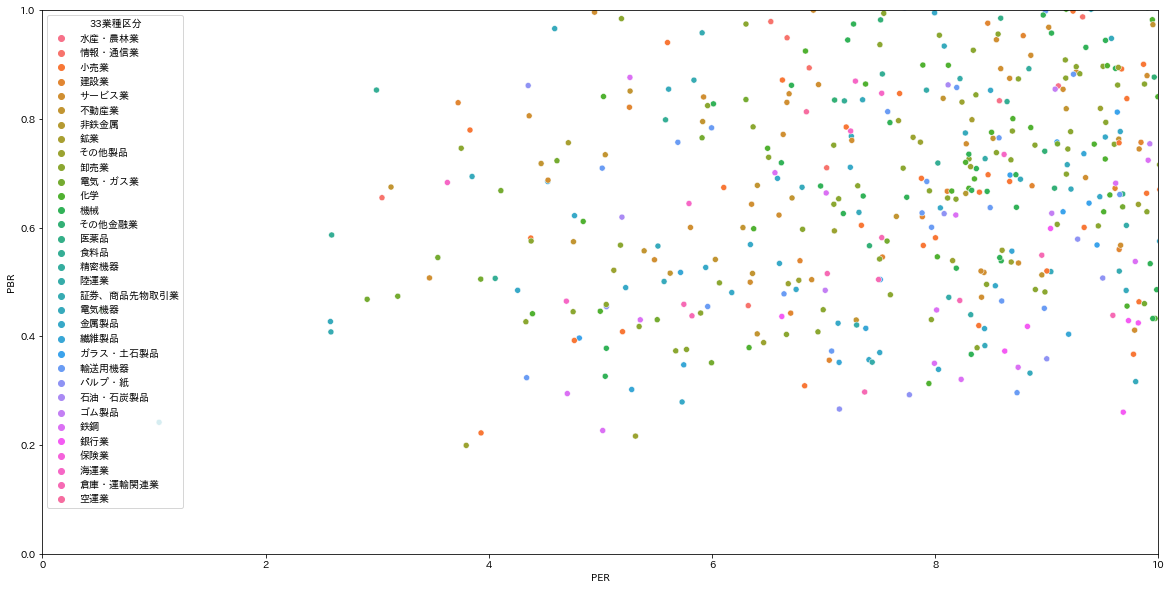

In [146]:
import seaborn as sns 

plt.figure(figsize=(20,10))
sns.scatterplot(data=toshodf2,x='PER',y='PBR',hue='33業種区分',legend='full')
plt.xlim(0,10)
plt.ylim(0,1)

(0.0, 1.0)

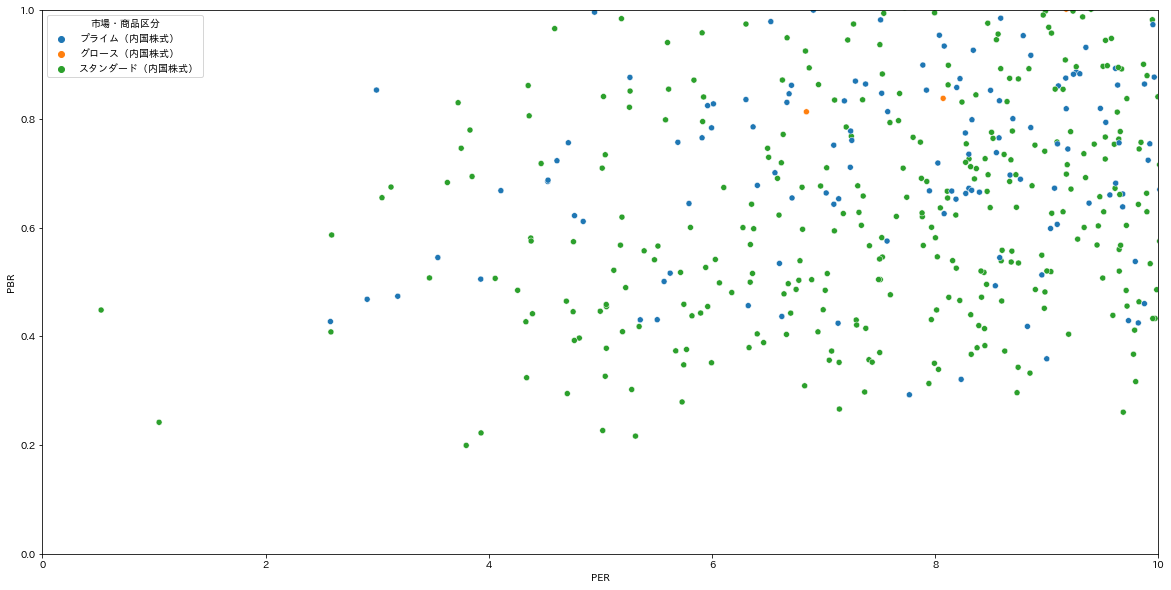

In [147]:
plt.figure(figsize=(20,10))
sns.scatterplot(data=toshodf2,x='PER',y='PBR',hue='市場・商品区分',legend='full')
plt.xlim(0,10)
plt.ylim(0,1)

In [148]:
toshodf2['PER'] = pd.to_numeric(toshodf2['PER'], errors='coerce')

In [149]:
toshodf2[toshodf2['PER']>2000] 

,Ticker,PER,PBR,EPS,市場・商品区分,33業種区分,銘柄名
193,211A.T,inf,1.041272,0.00,スタンダード（内国株式）,建設業,カドス・コーポレーション
1348,4936.T,inf,1.202953,0.00,スタンダード（内国株式）,化学,アクシージア
1488,5449.T,2051.7483,0.671863,1.43,スタンダード（内国株式）,鉄鋼,大阪製鐵


In [158]:
toshodf2['市場・商品区分'].unique()

array(['プライム（内国株式）', 'グロース（内国株式）', 'スタンダード（内国株式）'], dtype=object)

In [159]:
valuedf2 = toshodf2[(toshodf2['PER']<15)&(toshodf2['PBR']<1)&(toshodf2['市場・商品区分']=='プライム（内国株式）')]
valuedf2

,Ticker,PER,PBR,EPS,市場・商品区分,33業種区分,銘柄名
0,1301.T,8.575048,0.833403,576.09,プライム（内国株式）,水産・農林業,極洋
2,1333.T,9.103448,0.860734,145.00,プライム（内国株式）,水産・農林業,マルハニチロ
50,1605.T,8.328967,0.798517,362.59,プライム（内国株式）,鉱業,ＩＮＰＥＸ
52,1662.T,4.712336,0.756158,339.11,プライム（内国株式）,鉱業,石油資源開発
53,1663.T,12.735643,0.984104,297.59,プライム（内国株式）,鉱業,Ｋ＆Ｏエナジーグループ
...,...,...,...,...,...,...,...
3213,9932.T,14.850971,0.759496,96.29,プライム（内国株式）,卸売業,杉本商事
3220,9956.T,13.018510,0.992263,257.71,プライム（内国株式）,小売業,バローホールディングス
3236,9990.T,10.688043,0.787295,74.85,プライム（内国株式）,小売業,サックスバー ホールディングス
3237,9991.T,9.188073,0.744646,164.67,プライム（内国株式）,卸売業,ジェコス


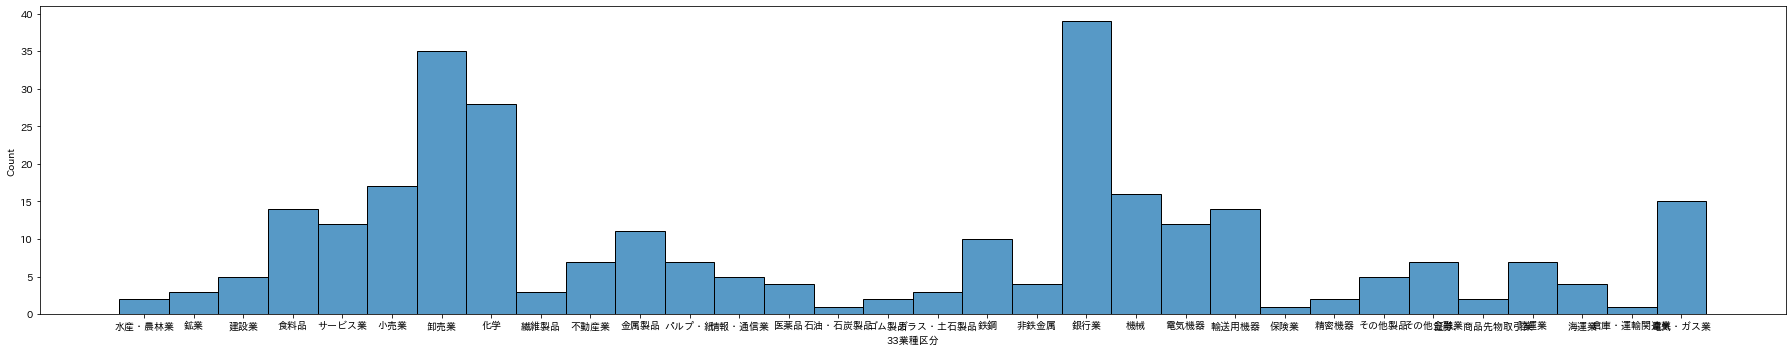

In [160]:
plt.figure(figsize=(25,5))
sns.histplot(x='33業種区分',data=valuedf2)
plt.tight_layout()
plt.show()

In [162]:
valuedf2[valuedf2['33業種区分']=='卸売業']

,Ticker,PER,PBR,EPS,市場・商品区分,33業種区分,銘柄名
396,2733.T,10.747257,0.855535,287.05,プライム（内国株式）,卸売業,あらた
568,3151.T,7.091500,0.643075,203.06,プライム（内国株式）,卸売業,バイタルケーエスケー・ホールディングス
570,3154.T,13.280492,0.909963,61.82,プライム（内国株式）,卸売業,メディアスホールディングス
581,3176.T,9.634323,0.862284,159.43,プライム（内国株式）,卸売業,三洋貿易
668,3388.T,9.874923,0.864149,243.85,プライム（内国株式）,卸売業,明治電機工業
2173,7130.T,9.528301,0.793663,275.60,プライム（内国株式）,卸売業,ヤマエグループホールディングス
2305,7420.T,10.774736,0.823153,176.06,プライム（内国株式）,卸売業,佐鳥電機
2323,7459.T,14.536366,0.938328,196.06,プライム（内国株式）,卸売業,メディパルホールディングス
2329,7466.T,9.295548,0.883071,260.77,プライム（内国株式）,卸売業,ＳＰＫ
2330,7467.T,13.982353,0.736527,267.48,プライム（内国株式）,卸売業,萩原電気ホールディングス


In [150]:
# 米国株　ARMやNvidiaなどの動きから翌日のSoftbank Gや半導体関連の企業の動きがどれくらい当てはまるか検証してみたい：
